In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt





from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)



In [ ]:
import joblib

In [ ]:
data = pd.read_csv('..\\data\\raw\\diabetes_dataset.csv')               

A cursory look at different columns within the dataset to look at fields that may or may not be required

In [ ]:
data.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [ ]:
data.dtypes

age                                     int64
gender                                    str
ethnicity                                 str
education_level                           str
income_level                              str
employment_status                         str
smoking_status                            str
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                   

**Handle Missing Values**

In [ ]:
total_null_values = 0
for cols in data:
    print("Null Values in  column",cols," : " , data[cols].isnull().sum())
    total_null_values = total_null_values + data[cols].isnull().sum()

print("Total Null Values : " , total_null_values)

Null Values in  column age  :  0
Null Values in  column gender  :  0
Null Values in  column ethnicity  :  0
Null Values in  column education_level  :  0
Null Values in  column income_level  :  0
Null Values in  column employment_status  :  0
Null Values in  column smoking_status  :  0
Null Values in  column alcohol_consumption_per_week  :  0
Null Values in  column physical_activity_minutes_per_week  :  0
Null Values in  column diet_score  :  0
Null Values in  column sleep_hours_per_day  :  0
Null Values in  column screen_time_hours_per_day  :  0
Null Values in  column family_history_diabetes  :  0
Null Values in  column hypertension_history  :  0
Null Values in  column cardiovascular_history  :  0
Null Values in  column bmi  :  0
Null Values in  column waist_to_hip_ratio  :  0
Null Values in  column systolic_bp  :  0
Null Values in  column diastolic_bp  :  0
Null Values in  column heart_rate  :  0
Null Values in  column cholesterol_total  :  0
Null Values in  column hdl_cholesterol  : 

In [ ]:
pd.get_dummies(data, columns = ["gender"])

,age,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,...,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,gender_Female,gender_Male,gender_Other
0,58,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,...,136,236,6.36,8.18,29.6,Type 2,1,False,True,False
1,48,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,...,93,150,2.00,5.63,23.0,No Diabetes,0,True,False,False
2,60,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,...,118,195,5.07,7.51,44.7,Type 2,1,False,True,False
3,74,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,...,139,253,5.28,9.03,38.2,Type 2,1,True,False,False
4,46,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,...,137,184,12.74,7.20,23.5,Type 2,1,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,6.4,...,113,109,14.58,5.55,26.0,Pre-Diabetes,0,False,True,False
99996,41,White,Graduate,Middle,Employed,Never,3,76,8.8,6.8,...,96,146,9.02,5.97,24.4,Pre-Diabetes,0,True,False,False
99997,57,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,5.0,...,93,132,2.57,5.21,27.6,No Diabetes,0,True,False,False
99998,47,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,6.7,...,106,117,9.81,5.53,26.4,Pre-Diabetes,0,True,False,False


In [ ]:
data['diabetes_stage'].unique()

<StringArray>
['Type 2', 'No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 1']
Length: 5, dtype: str

In [ ]:
for columns in data : 
    print("Number of unique values in" , columns , " : " , data[columns].nunique())
    print("Uniques values in " , columns )
    print(data[columns].unique())

Number of unique values in age  :  73
Uniques values in  age
[58 48 60 74 46 75 62 42 59 43 54 19 22 41 34 55 35 27 73 51 52 32 56 40
 45 80 50 33 63 30 53 29 26 38 67 44 39 66 65 37 47 31 72 49 18 89 68 28
 85 25 71 24 61 69 57 36 90 64 87 20 84 78 70 76 83 79 23 81 77 21 86 82
 88]
Number of unique values in gender  :  3
Uniques values in  gender
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
Number of unique values in ethnicity  :  5
Uniques values in  ethnicity
<StringArray>
['Asian', 'White', 'Hispanic', 'Black', 'Other']
Length: 5, dtype: str
Number of unique values in education_level  :  4
Uniques values in  education_level
<StringArray>
['Highschool', 'Graduate', 'Postgraduate', 'No formal']
Length: 4, dtype: str
Number of unique values in income_level  :  5
Uniques values in  income_level
<StringArray>
['Lower-Middle', 'Middle', 'Low', 'Upper-Middle', 'High']
Length: 5, dtype: str
Number of unique values in employment_status  :  4
Uniques values in  employment

In [ ]:
pd.get_dummies(data, columns = ["gender", "diabetes_stage",'smoking_status'])

,age,ethnicity,education_level,income_level,employment_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,...,gender_Male,gender_Other,diabetes_stage_Gestational,diabetes_stage_No Diabetes,diabetes_stage_Pre-Diabetes,diabetes_stage_Type 1,diabetes_stage_Type 2,smoking_status_Current,smoking_status_Former,smoking_status_Never
0,58,Asian,Highschool,Lower-Middle,Employed,0,215,5.7,7.9,7.9,...,True,False,False,False,False,False,True,False,False,True
1,48,White,Highschool,Middle,Employed,1,143,6.7,6.5,8.7,...,False,False,False,True,False,False,False,False,True,False
2,60,Hispanic,Highschool,Middle,Unemployed,1,57,6.4,10.0,8.1,...,True,False,False,False,False,False,True,False,False,True
3,74,Black,Highschool,Low,Retired,0,49,3.4,6.6,5.2,...,False,False,False,False,False,False,True,False,False,True
4,46,White,Graduate,Middle,Retired,1,109,7.2,7.4,5.0,...,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Other,Graduate,Upper-Middle,Unemployed,1,136,8.3,6.4,4.5,...,True,False,False,False,True,False,False,False,True,False
99996,41,White,Graduate,Middle,Employed,3,76,8.8,6.8,4.8,...,False,False,False,False,True,False,False,False,False,True
99997,57,Black,No formal,Upper-Middle,Employed,4,121,9.9,5.0,6.1,...,False,False,False,True,False,False,False,False,True,False
99998,47,Black,Highschool,Lower-Middle,Retired,3,52,5.9,6.7,0.5,...,False,False,False,False,True,False,False,False,False,True


Dropping Unnecessary Features

In [ ]:
data = data.drop(columns=["ethnicity","education_level","income_level", "employment_status"])

One hot Encoding for Features with Categorical Values

In [ ]:
new_data = pd.get_dummies(data, columns = ["gender", "diabetes_stage",'smoking_status'])

Baseline Model Training and Evaluation

Binary Classification

Splitting of Data into Training and Testing Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = new_data.drop('diagnosed_diabetes', axis=1)
y = new_data['diagnosed_diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # transform ONLY — never fit_transform on test!
X_train.shape, X_test.shape, y_train.shape, y_test.shape






((80000, 34), (20000, 34), (80000,), (20000,))

Importing Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)

Logistic Regresion

ROC AUC: 0.9999986041666666


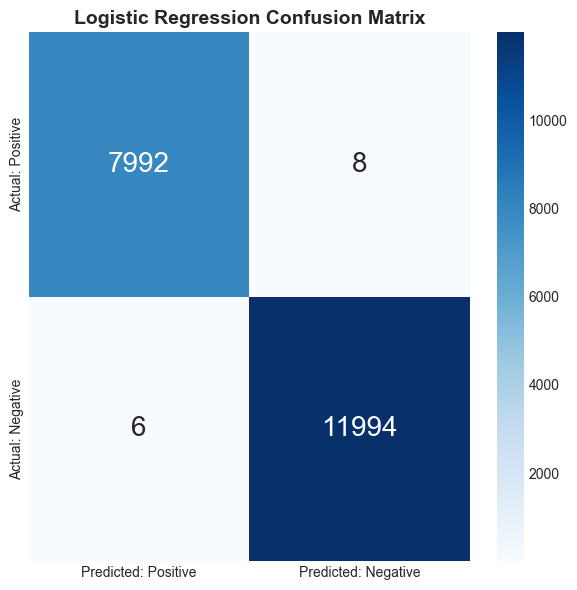

In [ ]:
#Task  3: Train Machine Learning Models
# Logistic Regression

# Train logistic regression
model_name= 'Logistic_Regression'
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]  # probability of survival
y_pred = model.predict(X_test)                # class label (0 or 1)
probs = model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC
auc_score = roc_auc_score(y_test, probs)
print(f'ROC AUC: {auc_score}')

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=['Predicted: Positive', 'Predicted: Negative'],
            yticklabels=['Actual: Positive', 'Actual: Negative'],
            annot_kws={'size': 20})
plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate all metrics manually (to understand the formulas)
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

ROC AUC: 0.999375


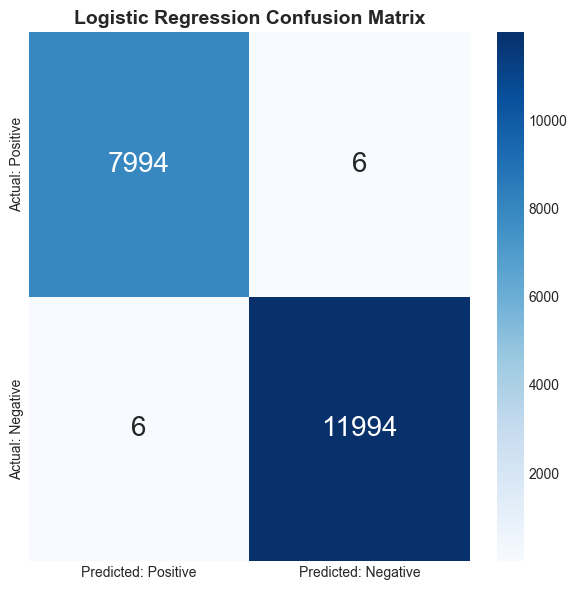

In [ ]:
#Task  3: Train Machine Learning Models
# Logistic Regression

# Train logistic regression
model_name= 'Decision Tree'
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]  # probability of survival
y_pred = model.predict(X_test)                # class label (0 or 1)
probs = model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC
auc_score = roc_auc_score(y_test, probs)
print(f'ROC AUC: {auc_score}')

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Positive', 'Predicted: Negative'],
            yticklabels=['Actual: Positive', 'Actual: Negative'],
            annot_kws={'size': 20})
plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(model, '..\\models\\binary_log_reg_model.joblib')

['..\\models\\binary_log_reg_model.joblib']

ROC AUC: 0.999375


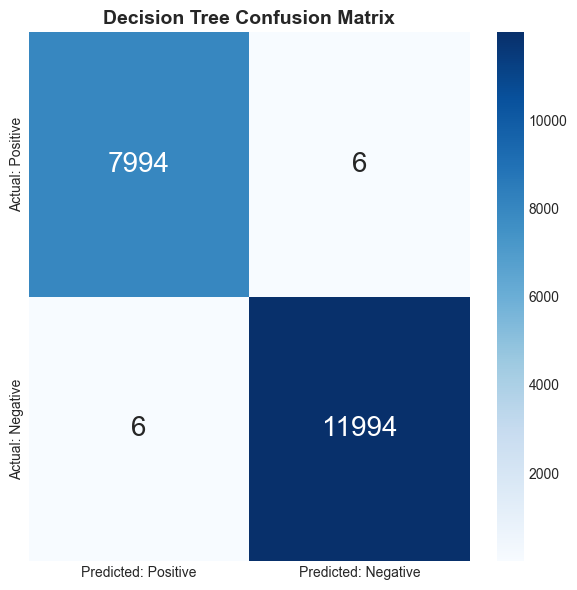

In [ ]:

model_name= 'Decision Tree'
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]  # probability of survival
y_pred = model.predict(X_test)                # class label (0 or 1)
probs = model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC
auc_score = roc_auc_score(y_test, probs)
print(f'ROC AUC: {auc_score}')

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=['Predicted: Positive', 'Predicted: Negative'],
            yticklabels=['Actual: Positive', 'Actual: Negative'],
            annot_kws={'size': 20})
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(model, '..\\models\\binary_decisiontree_model.joblib')

['..\\models\\binary_decisiontree_model.joblib']

KNN

ROC AUC: 0.9998907083333333


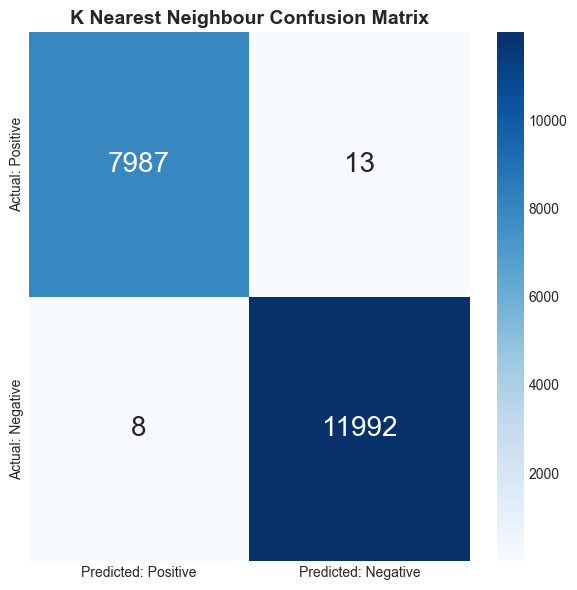

In [ ]:

model_name= 'KNN'
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]  # probability of survival
y_pred = model.predict(X_test)                # class label (0 or 1)
probs = model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC
auc_score = roc_auc_score(y_test, probs)
print(f'ROC AUC: {auc_score}')

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=['Predicted: Positive', 'Predicted: Negative'],
             yticklabels=['Actual: Positive', 'Actual: Negative'],
            annot_kws={'size': 20})
plt.title('K Nearest Neighbour Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
joblib.dump(model, '..\\models\\binary_KNN_model.joblib')

MULTI CLASS CLASSIFICATION

In [ ]:
new_data = []
new_data = pd.get_dummies(data, columns = ["gender",'smoking_status'])

In [ ]:
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = new_data.drop('diabetes_stage', axis=1)
y = new_data['diabetes_stage']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # transform ONLY — never fit_transform on test!
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80000, 30), (20000, 30), (80000,), (20000,))

In [ ]:
dlabels = new_data['diabetes_stage'].unique()
print(dlabels)


<StringArray>
['Type 2', 'No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 1']
Length: 5, dtype: str


In [ ]:
#Task  3: Train Machine Learning Models
# Logistic Regression

# Train logistic regression
model_name= 'Logistic_Regression'
model = LogisticRegression( solver='lbfgs',max_iter=20)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]  # probability of survival
y_pred = model.predict(X_test)                # class label (0 or 1)
probs = model.predict_proba(X_test)[:, 1]

#print('📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=dlabels))

print(f'\n🎯 Training Accuracy : {model.score(X_train, y_train)*100:.2f}%')
print(f'🎯 Testing  Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%')

              precision    recall  f1-score   support

      Type 2       0.00      0.00      0.00        56
 No Diabetes       0.86      0.78      0.82      1596
Pre-Diabetes       0.94      0.97      0.96      6369
 Gestational       0.00      0.00      0.00        24
      Type 1       1.00      1.00      1.00     11955

    accuracy                           0.97     20000
   macro avg       0.56      0.55      0.56     20000
weighted avg       0.96      0.97      0.97     20000


🎯 Training Accuracy : 96.98%
🎯 Testing  Accuracy : 96.92%


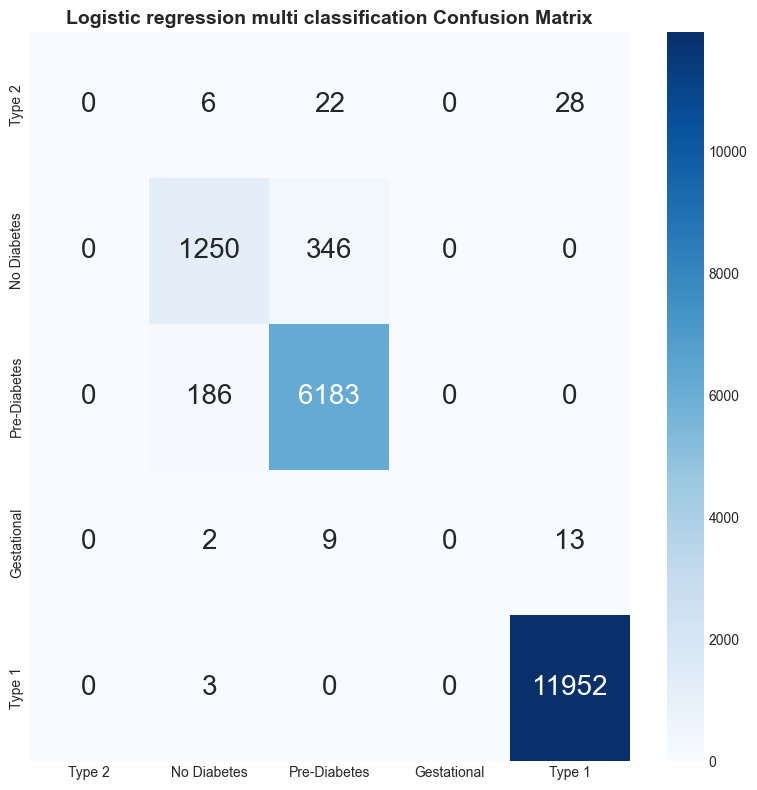

In [ ]:
# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=dlabels,
            yticklabels=dlabels,
            annot_kws={'size': 20})

#plt.figure(figsize=(8,8))
plt.title('Logistic regression multi classification Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Find optimal K using cross-validation
k_range = range(1, 10)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f'🏆 Best K = {best_k} with CV Accuracy = {max(cv_scores)*100:.2f}%')

# Train final model with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(f'\n🎯 Training Accuracy : {knn.score(X_train, y_train)*100:.2f}%')
print(f'🎯 Testing  Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%')

KeyboardInterrupt: 

In [ ]:
data.info()